# Simulación Avanzada de la Ecuación de Calor en 2D con PINNs

## Limitaciones del modelo vanilla-PINN y planteamiento general

Una PINN (Physics‑Informed Neural Network) convencional aproxima la solución de una EDP específica aprendiendo a satisfacer simultáneamente la ecuación diferencial, la condición inicial y las condiciones de contorno. Su principal limitación es que **cada problema requiere un entrenamiento independiente**; si se modifica el término fuente o las condiciones de contorno, la red debe ser reentrenada desde cero.

En este notebook abordamos distintos escenarios de conducción del calor en una placa cuadrada $[0,1]\times[0,1]$, usando siempre la misma arquitectura base pero reentrenando para cada caso. Exploramos:

1. **Caso base** – Fuente nula, bordes a $0$, condición inicial $u(x,y,0)=\sin(\pi x)\sin(\pi y)$.
2. **Dos fuentes interiores** – Placa fría ($u_0=0$) con dos focos gaussianos en $(0.3,0.3)$ y $(0.7,0.7)$.
3. **Dos fuentes exteriores (esquinas opuestas)** – Placa fría con fuentes cerca de $(0,0)$ y $(1,1)$.
4. **Barra lateral caliente** – Placa fría, borde izquierdo ($x=0$) fijo a $1$, resto de bordes a $0$ y sin fuentes internas.

La ecuación general de calor con fuente es:
$$
u_t = \alpha \nabla^2 u + Q(x,y), \quad (x,y)\in[0,1]^2,\; t\in[0,T]
$$
con $\alpha=0.1$ (difusividad térmica). El residuo que la red debe minimizar es:
$$
r_\theta = u_t - \alpha(u_{xx}+u_{yy}) - Q(x,y)
$$

### Expresiones explícitas de $Q$ para cada caso

- **Caso base y barra lateral**: $Q(x,y)=0$.
- **Dos fuentes interiores**:  
  $$
  Q(x,y) = A\sum_{i=1}^{2} \exp\left(-\frac{(x-x_i)^2+(y-y_i)^2}{2\sigma^2}\right)
  $$
  con $A=8.0$, $\sigma=0.08$, $(x_1,y_1)=(0.3,0.3)$, $(x_2,y_2)=(0.7,0.7)$.
- **Dos fuentes exteriores (esquinas)**:  
  Misma forma pero con $(0.1,0.1)$ y $(0.9,0.9)$ para no solapar los bordes.

La condición de frontera para los casos 1‑3 es Dirichlet homogénea: $u=0$ en todo el borde. Para la barra lateral, tenemos $u(0,y,t)=1$, $u(1,y,t)=u(x,0,t)=u(x,1,t)=0$.

La condición inicial es $u(x,y,0)=\sin(\pi x)\sin(\pi y)$ para el caso base, y $u(x,y,0)=0$ para los demás (placa fría).

In [2]:
# Instalación de paquetes necesarios (ejecutar una sola vez)
!pip install -r requirements.txt

In [3]:
# Importaciones
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from IPython.display import clear_output, display
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider
import os

# Semillas para reproducibilidad
np.random.seed(123)
torch.manual_seed(123)

# Configuración del dispositivo
# En Google Colab, activar GPU en "Entorno de ejecución -> Cambiar tipo de ejecutable"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entrenando en: {device}")

# Parámetros físicos
alpha = 0.1          # difusividad térmica
T_final = 1.0        # tiempo final

# Hiperparámetros de la red (dependen del dispositivo)
if device.type == "cuda":
    neuronas = 100
    capas_ocultas = 6
    lr = 1e-3
else:
    neuronas = 50
    capas_ocultas = 5
    lr = 1e-3

epocas = 3000          # para caso base
epocas_casos = 2000    # para los demás casos

# Número de puntos de muestreo
N_r = 10000   # puntos interiores (PDE)
N_0 = 2000    # condición inicial
N_b = 2000    # puntos por cada borde (total 4*N_b)

# Visualización durante entrenamiento
mostrar_cada = 500

Entrenando en: cpu


## Solución analítica (caso base)

Para el caso base ($Q=0$, condiciones de contorno homogéneas y condición inicial $u(x,y,0)=\sin(\pi x)\sin(\pi y)$) podemos aplicar separación de variables. Suponiendo $u(x,y,t)=X(x)Y(y)T(t)$ e introduciendo en $u_t = \alpha(u_{xx}+u_{yy})$ se obtiene:

$$
\frac{T'}{\alpha T} = \frac{X''}{X} + \frac{Y''}{Y} = -\lambda
$$

Las condiciones de contorno $X(0)=X(1)=0$, $Y(0)=Y(1)=0$ fuerzan autovalores $\lambda_{n,m} = \pi^2(n^2+m^2)$ y autofunciones $\sin(n\pi x)\sin(m\pi y)$. La condición inicial selecciona $n=m=1$, dando:

$$
u(x,y,t) = e^{-2\alpha\pi^2 t} \sin(\pi x)\sin(\pi y)
$$

Esta expresión se usará exclusivamente para validar la PINN en el caso base.

<>:10: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:10: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/tmp/ipykernel_601473/424653204.py:10: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plt.title('Condición inicial: $u(x,y,0) = \sin(\pi x)\sin(\pi y)$')


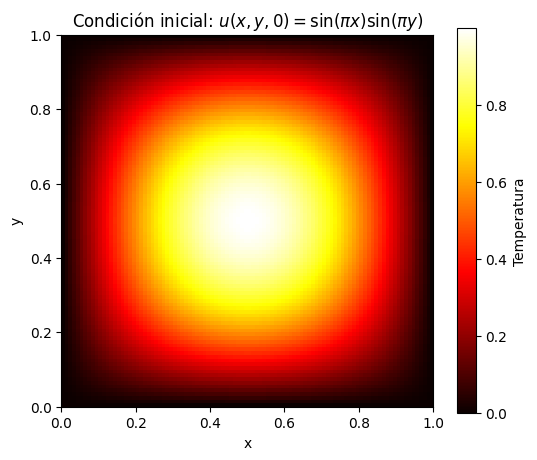

In [4]:
# Visualización de la condición inicial del caso base
x_vals = np.linspace(0, 1, 100)
y_vals = np.linspace(0, 1, 100)
X, Y = np.meshgrid(x_vals, y_vals)
U0 = np.sin(np.pi * X) * np.sin(np.pi * Y)

plt.figure(figsize=(6,5))
plt.imshow(U0, extent=[0,1,0,1], origin='lower', cmap='hot')
plt.colorbar(label='Temperatura')
plt.title('Condición inicial: $u(x,y,0) = \sin(\pi x)\sin(\pi y)$')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [5]:
def solucion_exacta(x, y, t, alpha=0.1):
    """Solución analítica del caso base."""
    return torch.exp(-2 * alpha * torch.pi**2 * t) * torch.sin(torch.pi * x) * torch.sin(torch.pi * y)

## Arquitectura de la red neuronal

La red es un MLP con 3 entradas $(x,y,t)$ y una salida $u_\theta(x,y,t)$. El número de neuronas y capas ocultas se adapta al hardware disponible (GPU vs CPU).

In [6]:
class RedPINN_2D(nn.Module):
    def __init__(self, neuronas=60, capas_ocultas=5):
        super().__init__()
        capas = [nn.Linear(3, neuronas), nn.Tanh()]
        for _ in range(capas_ocultas - 1):
            capas.append(nn.Linear(neuronas, neuronas))
            capas.append(nn.Tanh())
        capas.append(nn.Linear(neuronas, 1))
        self.red = nn.Sequential(*capas)

    def forward(self, x, y, t):
        return self.red(torch.cat([x, y, t], dim=1))

**¿Por qué `Tanh` y no `ReLU`?**  
La función de activación debe ser suave y tener segunda derivada no nula en casi todo su dominio. `ReLU` tiene derivada segunda cero en todas partes excepto en un punto, lo que impediría calcular $u_{xx}$ y $u_{yy}$ de forma útil. `Tanh` es infinitamente diferenciable y permite propagar gradientes de segundo orden sin problemas.

## Diferenciación automática y residuo de la PDE

La ecuación de calor en 2D con fuente es una **ecuación diferencial parcial parabólica** que modela la evolución temporal de la temperatura:
$$
u_t = \alpha (u_{xx} + u_{yy}) + Q(x,y)
$$

La PINN aproxima $u_\theta(x,y,t)$. Usando diferenciación automática (módulo `torch.autograd`) calculamos:

- $u_t$, $u_x$, $u_y$ (primeras derivadas)
- $u_{xx}$, $u_{yy}$ (segundas derivadas)

El residuo se define como $r_\theta = u_t - \alpha(u_{xx}+u_{yy}) - Q$. Durante el entrenamiento se minimiza $\mathbb{E}[r_\theta^2]$ en puntos de muestreo interiores, junto con pérdidas de condición inicial y frontera.

In [7]:
def derivada(u, x):
    """Primera derivada de u respecto a x, manteniendo el grafo."""
    return torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]

def residuo_pde(modelo, x, y, t, alpha, Q_func=None):
    """
    Calcula el residuo de la ecuación de calor.
    Si Q_func no es None, se resta su valor (fuente de calor).
    """
    x = x.clone().detach().requires_grad_(True)
    y = y.clone().detach().requires_grad_(True)
    t = t.clone().detach().requires_grad_(True)

    u = modelo(x, y, t)
    u_t = derivada(u, t)
    u_x = derivada(u, x)
    u_xx = derivada(u_x, x)
    u_y = derivada(u, y)
    u_yy = derivada(u_y, y)

    r = u_t - alpha * (u_xx + u_yy)
    if Q_func is not None:
        r = r - Q_func(x, y)
    return r

In [8]:
def loss_pinn(modelo, puntos, alpha, lambda_pde=1.0, lambda_ic=1.0, lambda_bc=1.0,
              Q_func=None, bc_func=None, ic_func=None):
    """
    puntos: (interiores, cond_inicial, bordes)
        Para borde no homogéneo, se pasa una tupla adicional.
    ic_func: función que devuelve el valor real de la condición inicial.
             Si es None, se asume u=sin(πx)sin(πy) (caso base).
    bc_func: función que calcula la pérdida de frontera. Si None, se asume u=0.
    """
    (x_r, y_r, t_r), (x_0, y_0, t_0), (x_b, y_b, t_b) = puntos

    # Pérdida PDE
    r = residuo_pde(modelo, x_r, y_r, t_r, alpha, Q_func)
    loss_pde = torch.mean(r**2)

    # Pérdida condición inicial
    u0_pred = modelo(x_0, y_0, t_0)
    if ic_func is None:
        u0_real = torch.sin(torch.pi * x_0) * torch.sin(torch.pi * y_0)
    else:
        u0_real = ic_func(x_0, y_0)
    loss_ic = torch.mean((u0_pred - u0_real)**2)

    # Pérdida de frontera
    if bc_func is None:
        u_b = modelo(x_b, y_b, t_b)
        loss_bc = torch.mean(u_b**2)
    else:
        loss_bc = bc_func(modelo, x_b, y_b, t_b)

    loss_total = lambda_pde * loss_pde + lambda_ic * loss_ic + lambda_bc * loss_bc
    return loss_total, loss_pde, loss_ic, loss_bc

## Muestreo de puntos de entrenamiento

Para evitar el sobreajuste a una malla fija, se muestrean aleatoriamente puntos en cada época. Así la red aprende a satisfacer las leyes físicas de forma continua en el dominio.

- **Interiores**: $(x,y,t)$ con $x,y\in(0,1)$, $t\in(0,T]$.
- **Condición inicial**: $t=0$.
- **Frontera**: puntos sobre $x=0$, $x=1$, $y=0$, $y=1$.

Para el caso de la barra lateral caliente, separamos el borde izquierdo ($x=0$) del resto porque su condición es $u=1$.

In [9]:
def muestrear_puntos_standard(N_r, N_0, N_b, T):
    """Muestreo para casos con Dirichlet homogéneo."""
    x_r = torch.rand(N_r, 1)
    y_r = torch.rand(N_r, 1)
    t_r = T * torch.rand(N_r, 1)

    x_0 = torch.rand(N_0, 1)
    y_0 = torch.rand(N_0, 1)
    t_0 = torch.zeros(N_0, 1)

    t_b = T * torch.rand(4 * N_b, 1)
    x_b = torch.cat([torch.zeros(N_b,1), torch.ones(N_b,1), torch.rand(N_b,1), torch.rand(N_b,1)], dim=0)
    y_b = torch.cat([torch.rand(N_b,1), torch.rand(N_b,1), torch.zeros(N_b,1), torch.ones(N_b,1)], dim=0)

    return (x_r, y_r, t_r), (x_0, y_0, t_0), (x_b, y_b, t_b)

def muestrear_puntos_borde_lateral(N_r, N_0, N_b, T):
    """Muestreo para barra lateral caliente: borde izquierdo (x=0) a u=1."""
    # Interiores
    x_r = torch.rand(N_r, 1)
    y_r = torch.rand(N_r, 1)
    t_r = T * torch.rand(N_r, 1)

    # Condición inicial
    x_0 = torch.rand(N_0, 1)
    y_0 = torch.rand(N_0, 1)
    t_0 = torch.zeros(N_0, 1)

    # Borde izquierdo: x=0, u=1
    x_left = torch.zeros(N_b, 1)
    y_left = torch.rand(N_b, 1)
    t_left = T * torch.rand(N_b, 1)

    # Otros bordes: x=1, y=0, y=1 -> u=0
    x_other = torch.cat([torch.ones(N_b,1), torch.rand(N_b,1), torch.rand(N_b,1)], dim=0)
    y_other = torch.cat([torch.rand(N_b,1), torch.zeros(N_b,1), torch.ones(N_b,1)], dim=0)
    t_other = T * torch.rand(3 * N_b, 1)

    return (x_r, y_r, t_r), (x_0, y_0, t_0), (x_left, y_left, t_left), (x_other, y_other, t_other)

# Función de pérdida para frontera mixta
def loss_bc_lateral(modelo, x_left, y_left, t_left, x_other, y_other, t_other):
    u_left = modelo(x_left, y_left, t_left)
    loss_left = torch.mean((u_left - 1)**2)
    u_other = modelo(x_other, y_other, t_other)
    loss_other = torch.mean(u_other**2)
    return loss_left + loss_other

## Funciones de fuentes de calor

Definimos las siguientes fuentes gaussianas:

- **Fuente centro**: $(0.5,0.5)$
- **Dos fuentes interiores**: $(0.3,0.3)$ y $(0.7,0.7)$
- **Dos fuentes exteriores (esquinas opuestas)**: $(0.1,0.1)$ y $(0.9,0.9)$

Para la barra lateral no se usa fuente interna ($Q=0$).

In [10]:
def fuente_centro(x, y, A=10.0, sigma=0.1):
    return A * torch.exp(-((x-0.5)**2 + (y-0.5)**2) / (2 * sigma**2))

def fuente_dos_puntos_interior(x, y, A=8.0, sigma=0.08):
    Q = torch.zeros_like(x)
    for (x0, y0) in [(0.3,0.3), (0.7,0.7)]:
        Q += A * torch.exp(-((x-x0)**2 + (y-y0)**2) / (2 * sigma**2))
    return Q

def fuente_dos_puntos_exterior(x, y, A=8.0, sigma=0.08):
    Q = torch.zeros_like(x)
    for (x0, y0) in [(0.1,0.1), (0.9,0.9)]:
        Q += A * torch.exp(-((x-x0)**2 + (y-y0)**2) / (2 * sigma**2))
    return Q

def ic_cero(x, y):
    """Condición inicial nula (placa fría)."""
    return torch.zeros_like(x)

## Función genérica de entrenamiento

Entrena una PINN, guarda el modelo final y el mejor (por pérdida total), y genera una gráfica de la evolución de las pérdidas.

In [11]:
def entrenar_pinn(caso_nombre, puntos, modelo, alpha, epocas, lr,
                  lambda_pde=1.0, lambda_ic=1.0, lambda_bc=1.0,
                  Q_func=None, bc_loss_func=None, ic_func=None,
                  save_best=True, verbose=True):
    """
    Entrena una PINN y guarda el modelo. Devuelve modelo entrenado e historial.
    """
    optimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
    historial = {"total": [], "pde": [], "ic": [], "bc": [], "mejor_loss": float('inf')}

    # Distinguir si es caso con borde lateral (4 tuplas) o estándar (3 tuplas)
    if len(puntos) == 4:
        (x_r,y_r,t_r), (x_0,y_0,t_0), (x_left,y_left,t_left), (x_other,y_other,t_other) = puntos
        for ep in range(1, epocas+1):
            optimizador.zero_grad()

            r = residuo_pde(modelo, x_r, y_r, t_r, alpha, Q_func)
            loss_pde = torch.mean(r**2)

            u0_pred = modelo(x_0, y_0, t_0)
            if ic_func is None:
                u0_real = torch.sin(torch.pi * x_0) * torch.sin(torch.pi * y_0)
            else:
                u0_real = ic_func(x_0, y_0)
            loss_ic = torch.mean((u0_pred - u0_real)**2)

            loss_bc = bc_loss_func(modelo, x_left, y_left, t_left, x_other, y_other, t_other)

            loss_t = lambda_pde * loss_pde + lambda_ic * loss_ic + lambda_bc * loss_bc
            loss_t.backward()
            optimizador.step()

            historial["total"].append(loss_t.item())
            historial["pde"].append(loss_pde.item())
            historial["ic"].append(loss_ic.item())
            historial["bc"].append(loss_bc.item())

            if save_best and loss_t.item() < historial["mejor_loss"]:
                historial["mejor_loss"] = loss_t.item()
                torch.save(modelo.state_dict(), f"{caso_nombre}_mejor.pth")

            if verbose and ep % mostrar_cada == 0:
                print(f"{caso_nombre} - Época {ep:5d} | Total: {loss_t:.2e} | PDE: {loss_pde:.2e} | IC: {loss_ic:.2e} | BC: {loss_bc:.2e}")
    else:
        # Caso estándar (3 tuplas)
        (x_r,y_r,t_r), (x_0,y_0,t_0), (x_b,y_b,t_b) = puntos
        for ep in range(1, epocas+1):
            optimizador.zero_grad()

            loss_t, loss_pde, loss_ic, loss_bc = loss_pinn(
                modelo, ( (x_r,y_r,t_r), (x_0,y_0,t_0), (x_b,y_b,t_b) ), alpha,
                lambda_pde, lambda_ic, lambda_bc, Q_func, bc_loss_func, ic_func)

            loss_t.backward()
            optimizador.step()

            historial["total"].append(loss_t.item())
            historial["pde"].append(loss_pde.item())
            historial["ic"].append(loss_ic.item())
            historial["bc"].append(loss_bc.item())

            if save_best and loss_t.item() < historial["mejor_loss"]:
                historial["mejor_loss"] = loss_t.item()
                torch.save(modelo.state_dict(), f"{caso_nombre}_mejor.pth")

            if verbose and ep % mostrar_cada == 0:
                print(f"{caso_nombre} - Época {ep:5d} | Total: {loss_t:.2e} | PDE: {loss_pde:.2e} | IC: {loss_ic:.2e} | BC: {loss_bc:.2e}")

    torch.save(modelo.state_dict(), f"trained_models/{caso_nombre}.pth")

    # Graficar pérdidas
    plt.figure(figsize=(10,5))
    plt.semilogy(historial["total"], label='Total')
    plt.semilogy(historial["pde"], label='PDE')
    plt.semilogy(historial["ic"], label='IC')
    plt.semilogy(historial["bc"], label='BC')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.title(f'Curvas de pérdida - {caso_nombre}')
    plt.show()

    return modelo, historial

# Caso Base (solución analítica conocida)

Se entrena una PINN para el problema con $Q=0$, condición inicial seno y bordes a cero. Si ya existe un modelo guardado (`caso_base_mejor.pth` o `caso_base_final.pth`), se puede cargar para evitar reentrenar.

Entrenando caso base desde cero...
caso_base - Época   500 | Total: 8.86e-03 | PDE: 2.88e-03 | IC: 2.84e-03 | BC: 3.14e-03
caso_base - Época  1000 | Total: 4.28e-03 | PDE: 1.53e-03 | IC: 9.22e-04 | BC: 1.82e-03
caso_base - Época  1500 | Total: 2.33e-03 | PDE: 1.07e-03 | IC: 3.37e-04 | BC: 9.29e-04
caso_base - Época  2000 | Total: 1.20e-03 | PDE: 6.59e-04 | IC: 1.04e-04 | BC: 4.38e-04
caso_base - Época  2500 | Total: 6.42e-04 | PDE: 3.82e-04 | IC: 4.21e-05 | BC: 2.18e-04
caso_base - Época  3000 | Total: 3.78e-04 | PDE: 2.62e-04 | IC: 2.03e-05 | BC: 9.59e-05


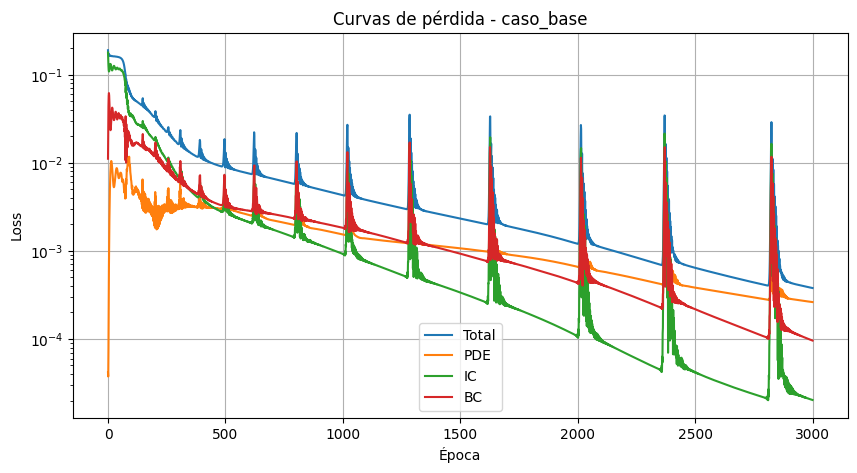

In [12]:
model_path = "trained_models/caso_base_mejor.pth"  # Cambiar a None o "" para reentrenar

if model_path and os.path.exists(model_path):
    print("Cargando modelo preentrenado para el caso base...")
    modelo_base = RedPINN_2D(neuronas, capas_ocultas).to(device)
    modelo_base.load_state_dict(torch.load(model_path, map_location=device))
else:
    print("Entrenando caso base desde cero...")
    puntos_base = muestrear_puntos_standard(N_r, N_0, N_b, T_final)
    puntos_base = tuple(tuple(t.to(device) for t in sub) for sub in puntos_base)
    modelo_base = RedPINN_2D(neuronas, capas_ocultas).to(device)
    modelo_base, hist_base = entrenar_pinn("caso_base", puntos_base, modelo_base, alpha, epocas, lr,
                                          Q_func=None, bc_loss_func=None, ic_func=None)

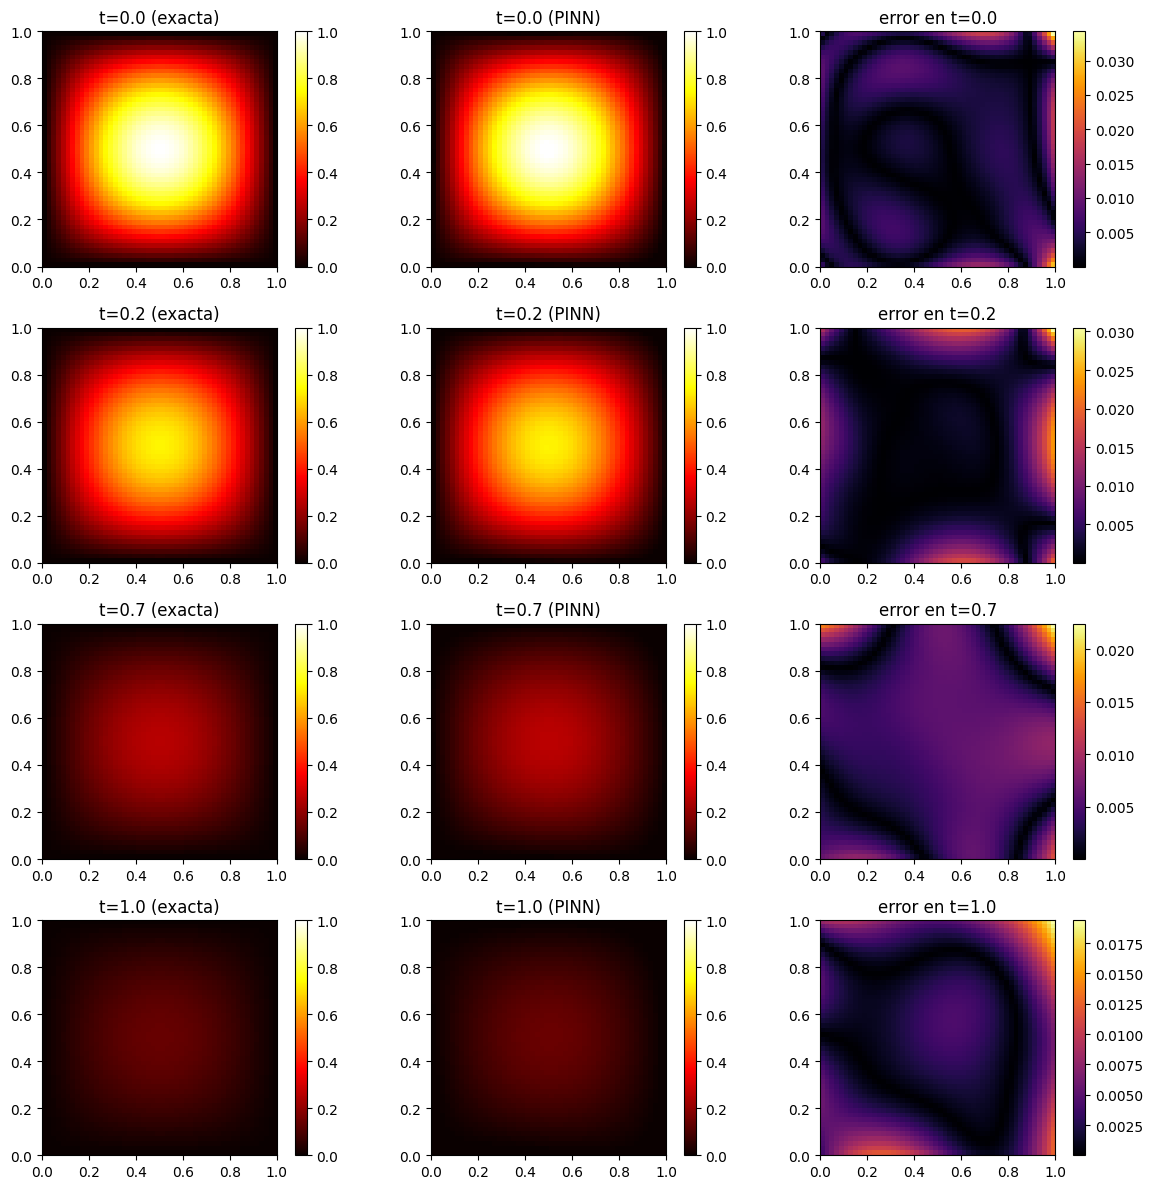

Error máximo global: 3.43e-02


In [13]:
def evaluar_malla(modelo, nx=50, ny=50, nt=20, exacta=False):
    x = torch.linspace(0, 1, nx, device=device)
    y = torch.linspace(0, 1, ny, device=device)
    t = torch.linspace(0, T_final, nt, device=device)
    X, Y, T_grid = torch.meshgrid(x, y, t, indexing='ij')
    x_flat = X.reshape(-1,1)
    y_flat = Y.reshape(-1,1)
    t_flat = T_grid.reshape(-1,1)
    with torch.no_grad():
        u_pred = modelo(x_flat, y_flat, t_flat).cpu().numpy().reshape(nx, ny, nt)
        if exacta:
            u_real = solucion_exacta(x_flat, y_flat, t_flat, alpha).cpu().numpy().reshape(nx, ny, nt)
            return x.cpu().numpy(), y.cpu().numpy(), t.cpu().numpy(), u_pred, u_real
    return x.cpu().numpy(), y.cpu().numpy(), t.cpu().numpy(), u_pred

x_vals, y_vals, t_vals, u_pred_base, u_real_base = evaluar_malla(modelo_base, exacta=True)

tiempos = [0.0, 0.2, 0.7, 1.0]
idx_tiempos = [int(t * (len(t_vals)-1)) for t in tiempos]

fig, axes = plt.subplots(len(tiempos), 3, figsize=(12, 12))
for i, (t_val, idx) in enumerate(zip(tiempos, idx_tiempos)):
    # Exacta
    im = axes[i,0].imshow(u_real_base[:,:,idx].T, origin='lower', extent=[0,1,0,1], cmap='hot', vmin=0, vmax=1)
    axes[i,0].set_title(f't={t_val} (exacta)')
    plt.colorbar(im, ax=axes[i,0])
    # PINN
    im = axes[i,1].imshow(u_pred_base[:,:,idx].T, origin='lower', extent=[0,1,0,1], cmap='hot', vmin=0, vmax=1)
    axes[i,1].set_title(f't={t_val} (PINN)')
    plt.colorbar(im, ax=axes[i,1])
    # Error absoluto
    err = np.abs(u_pred_base[:,:,idx] - u_real_base[:,:,idx])
    im = axes[i,2].imshow(err.T, origin='lower', extent=[0,1,0,1], cmap='inferno')
    axes[i,2].set_title(f'error en t={t_val}')
    plt.colorbar(im, ax=axes[i,2])

plt.tight_layout()
plt.show()

print(f"Error máximo global: {np.max(np.abs(u_pred_base - u_real_base)):.2e}")

## Entrenamiento para casos sin solución analítica

Cuando no se dispone de una solución exacta (fuentes internas, condiciones de frontera no homogéneas, etc.), los métodos numéricos tradicionales (diferencias finitas, elementos finitos) requieren discretizar el dominio y resolver sistemas lineales grandes, lo que puede ser costoso computacionalmente, especialmente en 3D o con mallados finos.

Las **ventajas de las PINNs** en estos contextos son:
- No necesitan malla; el muestreo es aleatorio y se puede refinar en regiones de interés.
- Aproximan la solución en todo el dominio continuo de forma diferenciable.
- Pueden incorporar datos experimentales fácilmente (problemas inversos).
- Una vez entrenadas, la evaluación es extremadamente rápida (inferencia).

Sin embargo, requieren ajuste de hiperparámetros (pesos de las pérdidas, arquitectura) y pueden ser lentas de entrenar. En los siguientes casos reentrenamos la PINN para cada nueva configuración física.

# Caso 2: Dos fuentes interiores

Placa inicialmente fría ($u_0=0$) con dos focos de calor en $(0.3,0.3)$ y $(0.7,0.7)$. Bordes a $0$. La fuente $Q$ está definida por `fuente_dos_puntos_interior`.

Entrenando caso fuentes interiores...
caso_fuentes_interiores - Época   500 | Total: 2.50e-02 | PDE: 9.34e-03 | IC: 1.12e-02 | BC: 4.49e-03
caso_fuentes_interiores - Época  1000 | Total: 1.30e-02 | PDE: 3.41e-03 | IC: 7.51e-03 | BC: 2.13e-03
caso_fuentes_interiores - Época  1500 | Total: 1.02e-02 | PDE: 2.55e-03 | IC: 6.46e-03 | BC: 1.20e-03
caso_fuentes_interiores - Época  2000 | Total: 9.59e-03 | PDE: 3.02e-03 | IC: 5.72e-03 | BC: 8.50e-04


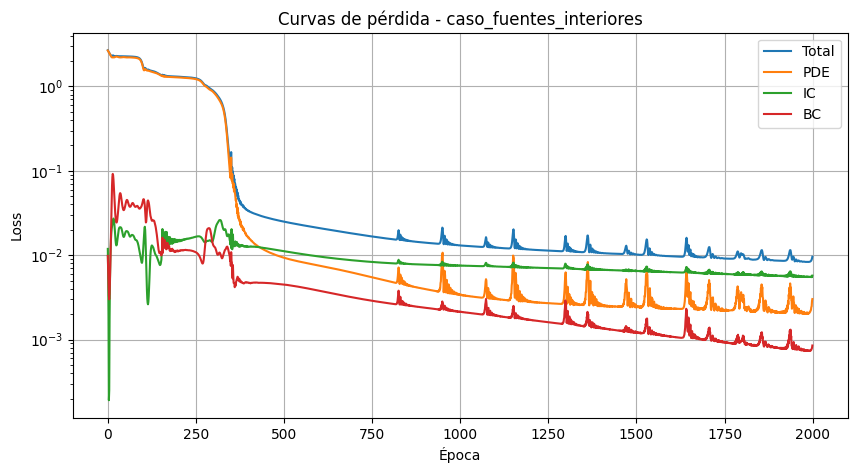

In [14]:
model_path2 = "trained_models/caso_fuentes_interiores_mejor.pth"

if model_path2 and os.path.exists(model_path2):
    print("Cargando modelo preentrenado para fuentes interiores...")
    modelo2 = RedPINN_2D(neuronas, capas_ocultas).to(device)
    modelo2.load_state_dict(torch.load(model_path2, map_location=device))
else:
    print("Entrenando caso fuentes interiores...")
    puntos2 = muestrear_puntos_standard(N_r, N_0, N_b, T_final)
    puntos2 = tuple(tuple(t.to(device) for t in sub) for sub in puntos2)
    modelo2 = RedPINN_2D(neuronas, capas_ocultas).to(device)
    modelo2, _ = entrenar_pinn("caso_fuentes_interiores", puntos2, modelo2, alpha,
                               epocas_casos, lr, Q_func=fuente_dos_puntos_interior,
                               bc_loss_func=None, ic_func=ic_cero)

In [15]:
def visualizador_pinn(modelo, titulo="Simulación PINN", nx=100, ny=100, t_min=0.0, t_max=T_final):
    """
    Crea un visualizador interactivo para un modelo PINN.

    Parámetros:
        modelo: Red neuronal entrenada (RedPINN_2D)
        titulo: Título base de la gráfica
        nx, ny: Resolución de la malla espacial
        t_min, t_max: Rango temporal del slider
    """
    # Crear malla espacial fija (se reutiliza para cada tiempo)
    x_lin = np.linspace(0, 1, nx)
    y_lin = np.linspace(0, 1, ny)
    Xg, Yg = np.meshgrid(x_lin, y_lin)
    x_tensor = torch.tensor(Xg.flatten(), dtype=torch.float32, device=device).reshape(-1, 1)
    y_tensor = torch.tensor(Yg.flatten(), dtype=torch.float32, device=device).reshape(-1, 1)

    def mostrar(t):
        clear_output(wait=True)  # Limpia la salida anterior para que el slider siga funcionando
        t_tensor = torch.full_like(x_tensor, t, device=device)
        with torch.no_grad():
            u_pred = modelo(x_tensor, y_tensor, t_tensor).cpu().numpy().reshape(nx, ny)
        plt.figure(figsize=(6, 5))
        im = plt.imshow(u_pred.T, origin='lower', extent=[0, 1, 0, 1], cmap='hot')
        plt.colorbar(im, label='Temperatura')
        plt.title(f'{titulo} - t = {t:.2f}')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.show()
        # Información adicional útil
        print(f"Temperatura mínima: {u_pred.min():.3f} | Máxima: {u_pred.max():.3f}")

    # Crear el slider interactivo
    interact(mostrar, t=FloatSlider(min=t_min, max=t_max, step=0.05, value=t_min))

In [16]:
visualizador_pinn(modelo2, titulo="Dos fuentes interiores")

interactive(children=(FloatSlider(value=0.0, description='t', max=1.0, step=0.05), Output()), _dom_classes=('w…

In [17]:
# Prueba en dos tiempos distintos
t_test1 = torch.tensor([[0.0]], device=device)
t_test2 = torch.tensor([[0.5]], device=device)
x_test = torch.tensor([[0.5]], device=device)
y_test = torch.tensor([[0.5]], device=device)
with torch.no_grad():
    u1 = modelo2(x_test, y_test, t_test1).item()
    u2 = modelo2(x_test, y_test, t_test2).item()
print(f"Temperatura en (0.5,0.5): t=0 -> {u1:.4f}, t=0.5 -> {u2:.4f}")

Temperatura en (0.5,0.5): t=0 -> -0.1299, t=0.5 -> 0.3574


# Caso 3: Dos fuentes exteriores (esquinas opuestas)

Similar al anterior, pero las fuentes están cerca de las esquinas $(0.1,0.1)$ y $(0.9,0.9)$. Placa fría inicial, bordes a $0$.

Entrenando caso fuentes exteriores...
caso_fuentes_exteriores - Época   500 | Total: 3.03e-01 | PDE: 2.37e-01 | IC: 1.21e-02 | BC: 5.39e-02
caso_fuentes_exteriores - Época  1000 | Total: 1.10e-02 | PDE: 5.70e-03 | IC: 3.52e-03 | BC: 1.74e-03
caso_fuentes_exteriores - Época  1500 | Total: 7.26e-03 | PDE: 2.58e-03 | IC: 3.06e-03 | BC: 1.62e-03
caso_fuentes_exteriores - Época  2000 | Total: 6.76e-03 | PDE: 2.20e-03 | IC: 3.02e-03 | BC: 1.53e-03


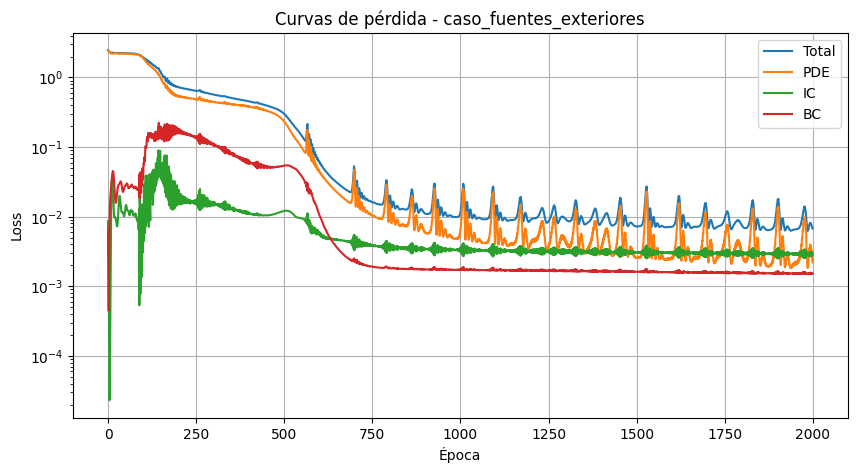

In [18]:
model_path3 = "trained_models/caso_fuentes_exteriores_mejor.pth"

if model_path3 and os.path.exists(model_path3):
    print("Cargando modelo preentrenado para fuentes exteriores...")
    modelo3 = RedPINN_2D(neuronas, capas_ocultas).to(device)
    modelo3.load_state_dict(torch.load(model_path3, map_location=device))
else:
    print("Entrenando caso fuentes exteriores...")
    puntos3 = muestrear_puntos_standard(N_r, N_0, N_b, T_final)
    puntos3 = tuple(tuple(t.to(device) for t in sub) for sub in puntos3)
    modelo3 = RedPINN_2D(neuronas, capas_ocultas).to(device)
    modelo3, _ = entrenar_pinn("caso_fuentes_exteriores", puntos3, modelo3, alpha,
                               epocas_casos, lr, Q_func=fuente_dos_puntos_exterior,
                               bc_loss_func=None, ic_func=ic_cero)

In [19]:
visualizador_pinn(modelo3, titulo="Dos fuentes exteriores (esquinas)")

interactive(children=(FloatSlider(value=0.0, description='t', max=1.0, step=0.05), Output()), _dom_classes=('w…

# Caso 4: Barra lateral caliente

Placa fría inicial ($u_0=0$), sin fuentes internas ($Q=0$), borde izquierdo ($x=0$) fijo a $1$, los demás bordes a $0$. Es un problema más realista de calentamiento lateral.

Entrenando caso barra lateral...
caso_barra_lateral - Época   500 | Total: 7.41e-02 | PDE: 5.09e-03 | IC: 1.37e-02 | BC: 5.53e-02
caso_barra_lateral - Época  1000 | Total: 5.61e-02 | PDE: 2.46e-03 | IC: 7.26e-03 | BC: 4.64e-02
caso_barra_lateral - Época  1500 | Total: 4.35e-02 | PDE: 3.16e-03 | IC: 4.83e-03 | BC: 3.55e-02
caso_barra_lateral - Época  2000 | Total: 3.37e-02 | PDE: 2.72e-03 | IC: 3.89e-03 | BC: 2.71e-02


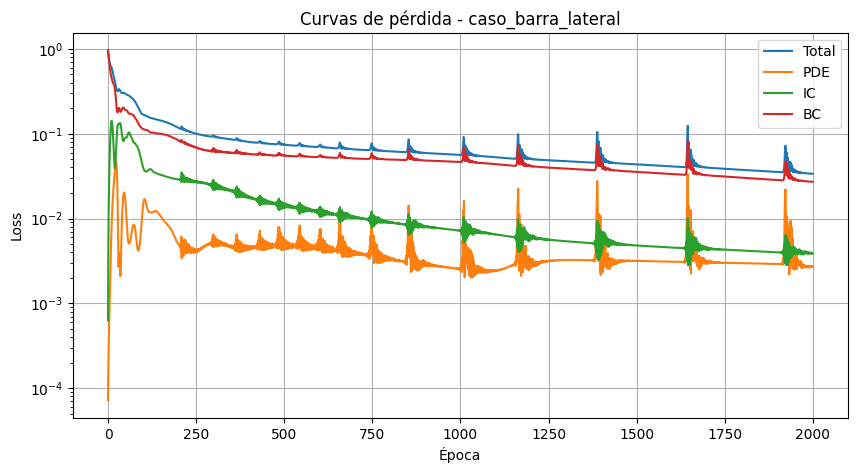

In [20]:
model_path4 = "trained_models/caso_barra_lateral_mejor.pth"

if model_path4 and os.path.exists(model_path4):
    print("Cargando modelo preentrenado para barra lateral...")
    modelo4 = RedPINN_2D(neuronas, capas_ocultas).to(device)
    modelo4.load_state_dict(torch.load(model_path4, map_location=device))
else:
    print("Entrenando caso barra lateral...")
    puntos4 = muestrear_puntos_borde_lateral(N_r, N_0, N_b, T_final)
    puntos4 = (
        (puntos4[0][0].to(device), puntos4[0][1].to(device), puntos4[0][2].to(device)),
        (puntos4[1][0].to(device), puntos4[1][1].to(device), puntos4[1][2].to(device)),
        (puntos4[2][0].to(device), puntos4[2][1].to(device), puntos4[2][2].to(device)),
        (puntos4[3][0].to(device), puntos4[3][1].to(device), puntos4[3][2].to(device))
    )
    modelo4 = RedPINN_2D(neuronas, capas_ocultas).to(device)
    modelo4, _ = entrenar_pinn("caso_barra_lateral", puntos4, modelo4, alpha,
                               epocas_casos, lr, Q_func=None, bc_loss_func=loss_bc_lateral, ic_func=ic_cero)

In [21]:
visualizador_pinn(modelo4, titulo="Barra lateral caliente")

interactive(children=(FloatSlider(value=0.0, description='t', max=1.0, step=0.05), Output()), _dom_classes=('w…

## Limitaciones y ajuste de hiperparámetros

**Limitaciones del enfoque PINN:**
- Sensibilidad a la inicialización y a los pesos relativos $\lambda_{\text{PDE}}, \lambda_{\text{IC}}, \lambda_{\text{BC}}$. Si no se equilibran, un término puede dominar y degradar la solución.
- Entrenamiento costoso para problemas con alta frecuencia o frentes abruptos (se requiere atención a la distribución de puntos).
- Sin garantía de convergencia global; pueden aparecer mínimos locales.

**Ajuste de las $\lambda$:**
En problemas con condiciones de contorno fuertes (p. ej., $u=1$ frente a $u=0$), es conveniente aumentar $\lambda_{\text{BC}}$ para forzar su cumplimiento. Una estrategia común es normalizar las pérdidas de modo que, al inicio del entrenamiento, las tres contribuciones tengan magnitudes similares. En este notebook hemos usado pesos unitarios ($1,1,1$), pero para casos como la barra lateral podría beneficiarse de un $\lambda_{\text{BC}}$ más alto (por ejemplo $10$). El ajuste fino requiere experimentación.

Para trabajos futuros se sugiere implementar **pérdidas adaptativas** (Learning Rate Annealing) o usar técnicas como la propuesta en el paper de referencia (He & Pathak, 2020), donde se emplea un autoencoder para codificar términos fuente y generalizar a casos no vistos, mejorando la eficiencia.